<a href="https://colab.research.google.com/github/AndresMontesDeOca/AnalisisDatos2/blob/main/Entregas/Actividad3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 3 - Reduccion de la Dimensionalidad y Clustering

## 1. Data Load

In [80]:
! pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# 1. Cargar el dataset de UCI
communities_and_crime = fetch_ucirepo(id=183)
X = communities_and_crime.data.features
y = communities_and_crime.data.targets

# 2. Combinar X e y en un solo DataFrame
data = pd.concat([X, y], axis=1)

# Reemplazar los '?' por NaN reales de numpy
data = data.replace('?', np.nan)

# Mostrar el resumen del DataFrame limpio
print(data.info())
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(100), int64(2), object(26)
memory usage: 1.9+ MB
None


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


## 2. Análisis exploratorio y preprocesamiento 

<Figure size 1000x600 with 0 Axes>

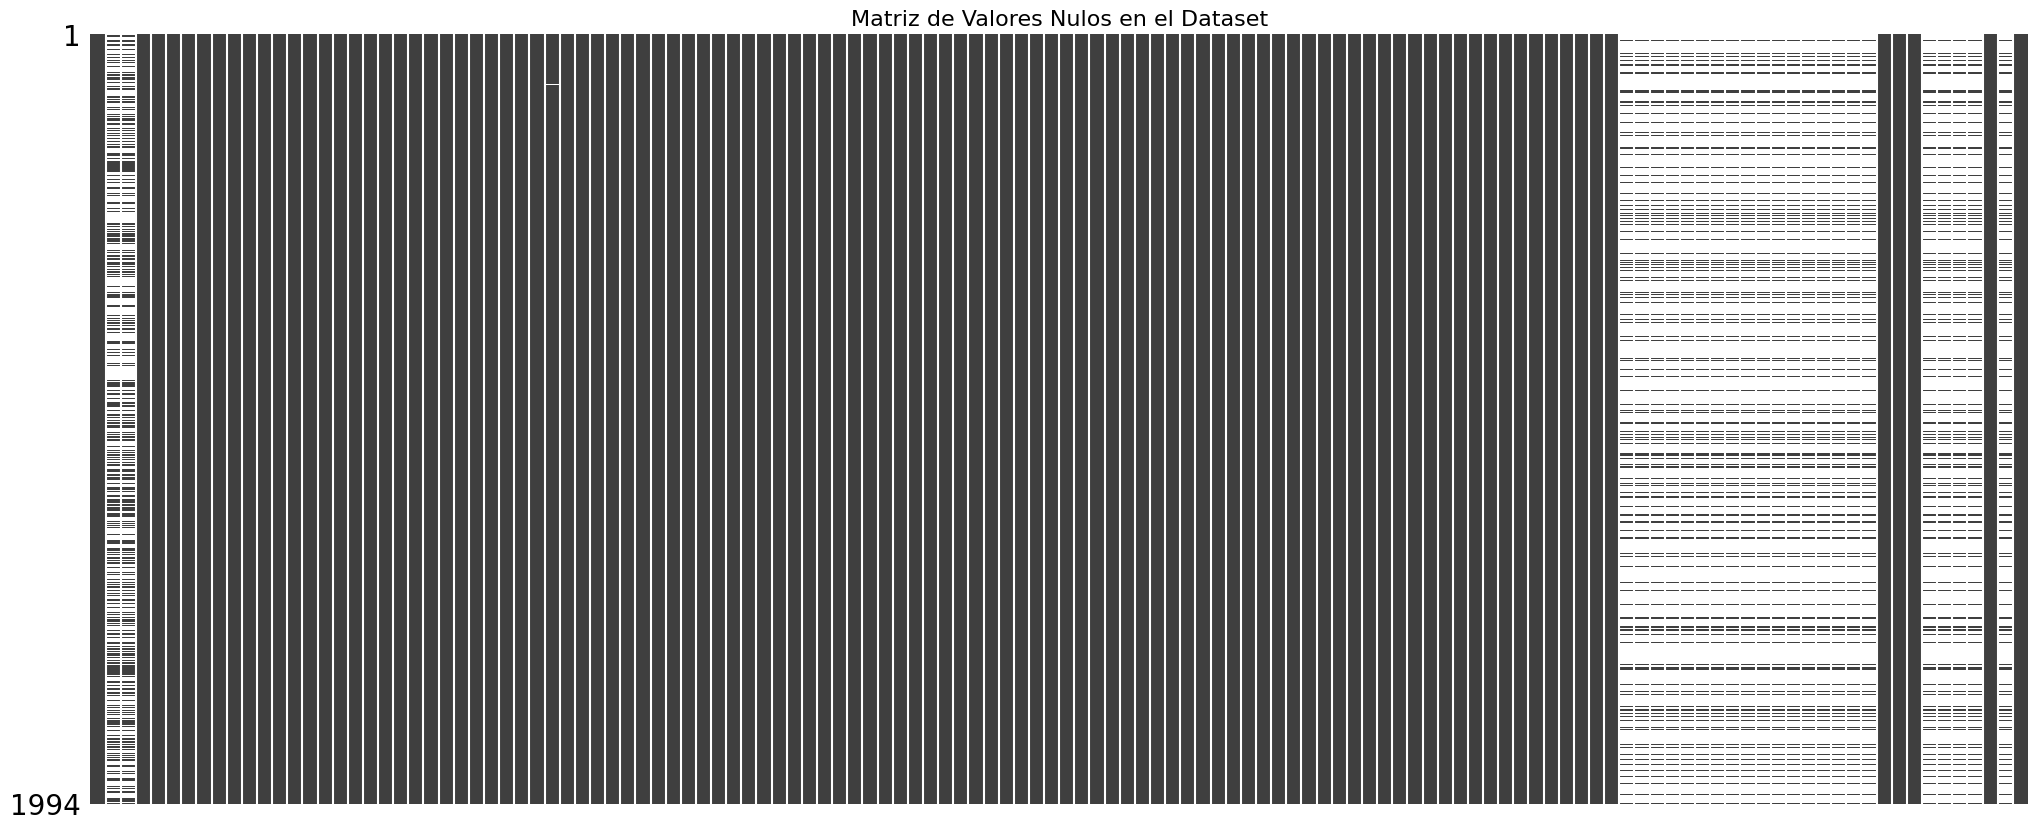

In [81]:
import missingno as msno
import matplotlib.pyplot as plt

# Visualizar la matriz de valores nulos
plt.figure(figsize=(10, 6))
msno.matrix(data, sparkline=False)
plt.title("Matriz de Valores Nulos en el Dataset", fontsize=16)
plt.show()

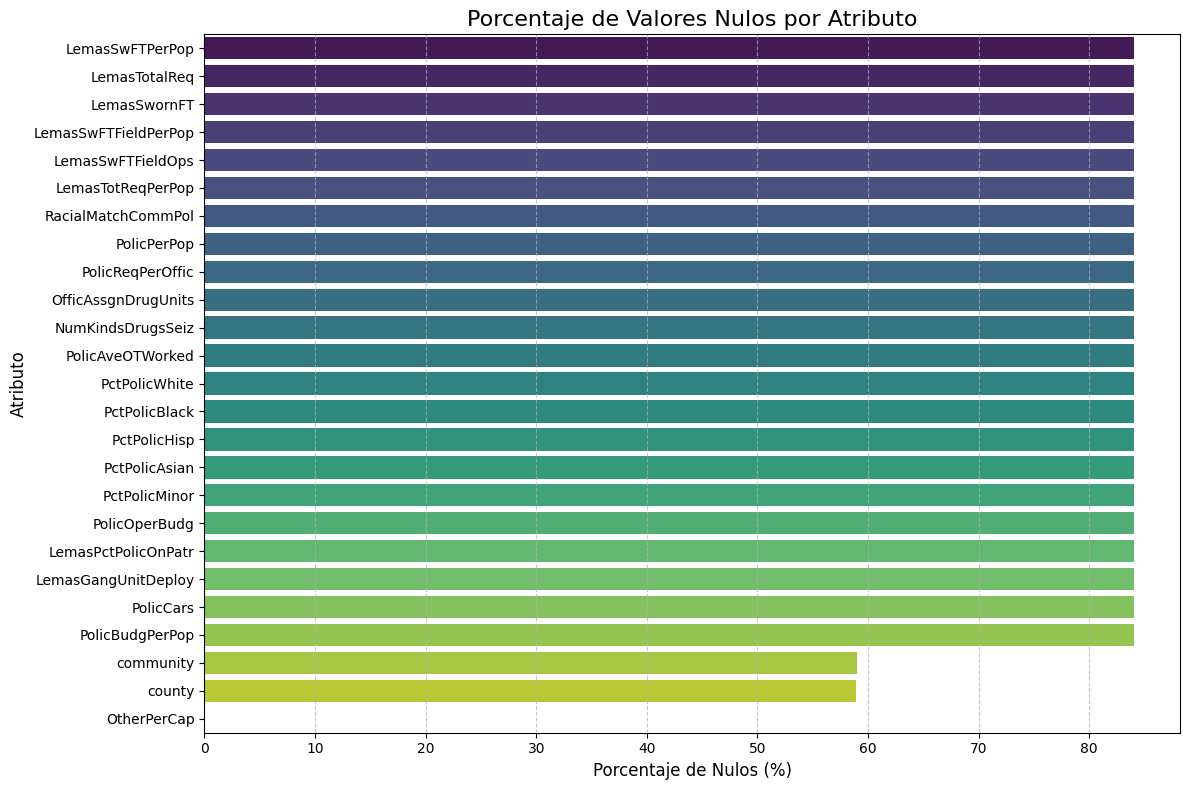

In [82]:
import seaborn as sns

# Calcular el porcentaje de nulos
null_percentages = (data.isnull().sum() / len(data)) * 100

# Filtrar solo las columnas con nulos y ordenarlas
null_cols = null_percentages[null_percentages > 0].sort_values(ascending=False).reset_index()
null_cols.columns = ['Atributo', 'Porcentaje_Nulos']

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x='Porcentaje_Nulos', y='Atributo', data=null_cols, palette='viridis', hue='Atributo', legend=False)

# Configurar etiquetas y títulos
plt.title('Porcentaje de Valores Nulos por Atributo', fontsize=16)
plt.xlabel('Porcentaje de Nulos (%)', fontsize=12)
plt.ylabel('Atributo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [83]:
# Contar valores nulos específicos para state, county y community
nulos_geograficos = data[['state', 'county', 'community']].isnull().sum()

for col, nulos in nulos_geograficos.items():
    total = len(data)
    pct = (nulos / total) * 100
    print(f"Columna '{col}': {nulos} valores nulos de {total} ({pct:.2f}%)")

Columna 'state': 0 valores nulos de 1994 (0.00%)
Columna 'county': 1174 valores nulos de 1994 (58.88%)
Columna 'community': 1177 valores nulos de 1994 (59.03%)


### Exploración de la Variable Objetivo: `ViolentCrimesPerPop`

In [84]:
# 1. Estadísticas descriptivas de la variable objetivo
print("Estadísticas Descriptivas de 'ViolentCrimesPerPop':")
display(data['ViolentCrimesPerPop'].describe())

# Verificar si hay valores nulos en el target
nulos_target = data['ViolentCrimesPerPop'].isnull().sum()
print(f"\nValores nulos en la variable objetivo: {nulos_target}")

Estadísticas Descriptivas de 'ViolentCrimesPerPop':


,ViolentCrimesPerPop
count,1994.000000
mean,0.237979
std,0.232985
min,0.000000
25%,0.070000
50%,0.150000
75%,0.330000
max,1.000000



Valores nulos en la variable objetivo: 0


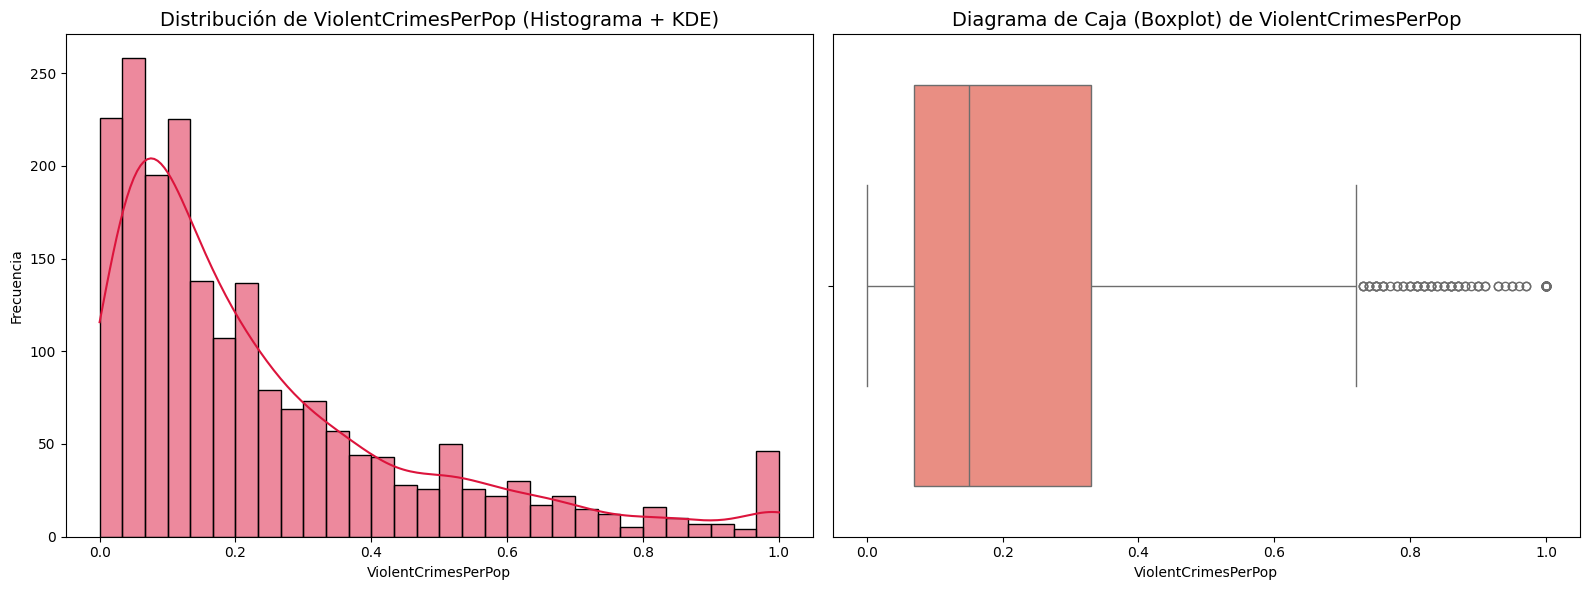

In [85]:
# 2. Visualización de la distribución del Target
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma con KDE
sns.histplot(data['ViolentCrimesPerPop'], kde=True, ax=axes[0], color='crimson', bins=30)
axes[0].set_title('Distribución de ViolentCrimesPerPop (Histograma + KDE)', fontsize=14)
axes[0].set_xlabel('ViolentCrimesPerPop')
axes[0].set_ylabel('Frecuencia')

# Boxplot para ver outliers y cuartiles
sns.boxplot(x=data['ViolentCrimesPerPop'], ax=axes[1], color='salmon')
axes[1].set_title('Diagrama de Caja (Boxplot) de ViolentCrimesPerPop', fontsize=14)
axes[1].set_xlabel('ViolentCrimesPerPop')

plt.tight_layout()
plt.show()

### Transformación a Problema de Clasificación Binaria
Definimos el umbral en **0.72** para identificar las comunidades con alta tasa de criminalidad violenta.

Distribución de la nueva variable objetivo 'HighCrime':
Clase 0: 1884 comunidades (94.48%)
Clase 1: 110 comunidades (5.52%)


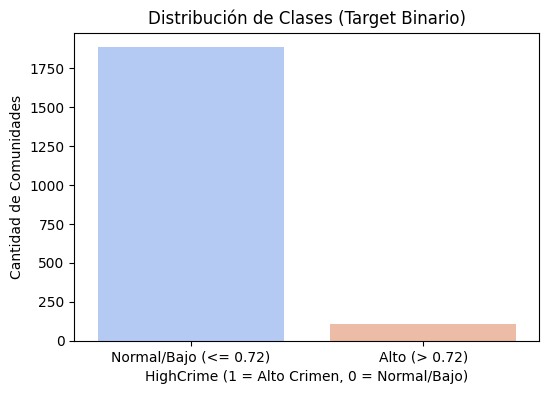

In [86]:
# Crear la nueva variable objetivo binaria
umbral = 0.72
data['HighCrime'] = (data['ViolentCrimesPerPop'] > umbral).astype(int)

# Calcular la distribución de las clases
counts = data['HighCrime'].value_counts()
percentages = data['HighCrime'].value_counts(normalize=True) * 100

print("Distribución de la nueva variable objetivo 'HighCrime':")
for val, count in counts.items():
    print(f"Clase {val}: {count} comunidades ({percentages[val]:.2f}%)")

# Graficar el balance de clases
plt.figure(figsize=(6, 4))
sns.countplot(x='HighCrime', data=data, palette='coolwarm', hue='HighCrime', legend=False)
plt.title('Distribución de Clases (Target Binario)')
plt.xlabel('HighCrime (1 = Alto Crimen, 0 = Normal/Bajo)')
plt.ylabel('Cantidad de Comunidades')
plt.xticks([0, 1], ['Normal/Bajo (<= 0.72)', 'Alto (> 0.72)'])
plt.show()

### Eliminación de la Variable Target Continua
Eliminamos `ViolentCrimesPerPop` para quedarnos únicamente con nuestro target binario `HighCrime`.

In [87]:
# Eliminar la columna del target continuo
if 'ViolentCrimesPerPop' in data.columns:
    data = data.drop(columns=['ViolentCrimesPerPop'])
    print("La columna 'ViolentCrimesPerPop' ha sido eliminada con éxito.")
else:
    print("La columna 'ViolentCrimesPerPop' no se encuentra en el DataFrame.")

# Verificar las columnas actuales
print(f"Dimensiones actuales del dataset: {data.shape}")

La columna 'ViolentCrimesPerPop' ha sido eliminada con éxito.
Dimensiones actuales del dataset: (1994, 128)


### Preprocesamiento y Construcción del Pipeline
A continuación, aislaremos nuestro objetivo (`target`), construiremos la matriz de características (`X`) eliminando variables no predictivas y crearemos un `Pipeline` para automatizar la imputación de nulos y el escalado de variables.

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

# 1. Aislar la variable objetivo binarizada
target = data['HighCrime'].copy()

# 2. Crear matriz de características X
# Eliminamos los targets y variables identificadoras que no aportan información predictiva
columnas_a_eliminar = ['HighCrime', 'ViolentCrimesPerPop', 'state', 'county', 'community', 'communityname', 'fold']

# Nos aseguramos de eliminar solo las columnas que sigan en el DataFrame
cols_eliminar_presentes = [col for col in columnas_a_eliminar if col in data.columns]
X = data.drop(columns=cols_eliminar_presentes)

# CORRECCIÓN: Al tener inicialmente símbolos '?' que luego reemplazamos por NaN,
# pandas dejó muchas columnas numéricas guardadas como tipo 'object' (texto).
# Vamos a forzar la conversión de vuelta a numérico para que OneHotEncoder no explote.
X = X.apply(pd.to_numeric, errors='ignore')

# 3. Identificar columnas numéricas y categóricas automáticamente
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# 4. Construir el ColumnTransformer
# Pipeline para variables numéricas (imputar con mediana y escalar)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas (imputar con moda y codificar One-Hot)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Ensamblamos el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# 5. Transformar la matriz X
X_processed = preprocessor.fit_transform(X)

# Mostrar dimensiones resultantes
print(f"Dimensiones de X (original sin identificadores): {X.shape}")
print(f"Dimensiones de X_processed (procesado): {X_processed.shape}")

Dimensiones de X (original sin identificadores): (1994, 122)
Dimensiones de X_processed (procesado): (1994, 122)


/tmp/ipykernel_37573/1947251686.py:21: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = X.apply(pd.to_numeric, errors='ignore')


## 3. Reducción de dimensionalidad y clustering 

 ### 3.a Aplicar reducción de dimensionalidad para obtener una representación compacta de los datos, conservando la mayor cantidad de información posible. 

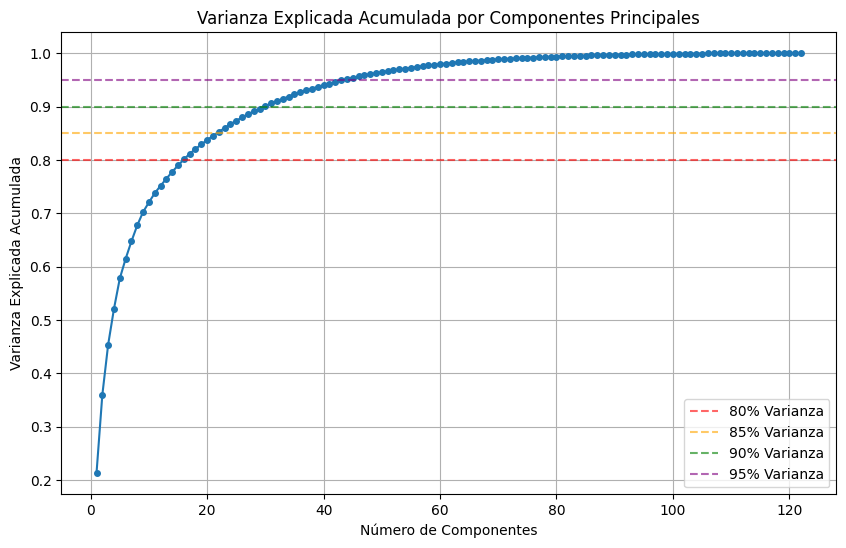

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Instanciar y ajustar PCA con todas las componentes para ver el panorama completo
pca_full = PCA(random_state=42)
pca_full.fit(X_processed)

# 2. Calcular la varianza explicada acumulada
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Graficar la varianza acumulada completa
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='-', markersize=4)

# Algunas líneas de referencia útiles
for threshold, color in zip([0.80, 0.85, 0.90, 0.95], ['r', 'orange', 'g', 'purple']):
    plt.axhline(y=threshold, color=color, linestyle='--', alpha=0.6, label=f'{int(threshold*100)}% Varianza')

plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [90]:
# Definir el valor de corte deseado (puedes modificar este valor: 0.80, 0.85, 0.90, etc.)
umbral = 0.80

# Instanciar y ajustar PCA con el umbral elegido
pca = PCA(n_components=umbral, random_state=42)
X_pca = pca.fit_transform(X_processed)

# Imprimir los detalles de la reducción
print(f"--- Resultados para el umbral {umbral} ---")
print(f"Número de componentes seleccionadas: {pca.n_components_}")
print(f"Porcentaje exacto de varianza acumulada retenida: {sum(pca.explained_variance_ratio_):.4f}")
print(f"Dimensiones finales de la matriz reducida: {X_pca.shape}")

--- Resultados para el umbral 0.8 ---
Número de componentes seleccionadas: 16
Porcentaje exacto de varianza acumulada retenida: 0.8009
Dimensiones finales de la matriz reducida: (1994, 16)


### 3.b Entrenamiento de Algoritmos de Clustering de Distinta Naturaleza

Para esta sección utilizaremos dos algoritmos de distinta familia para evaluar cómo capturan la estructura de nuestros datos:



- **Algoritmo 1 (Particional / Basado en Centroides)**: **K-Means**. Asume que los clusters son esféricos y de varianza similar.

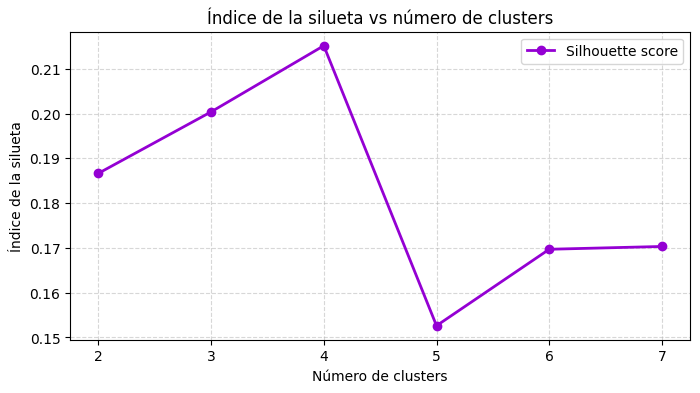

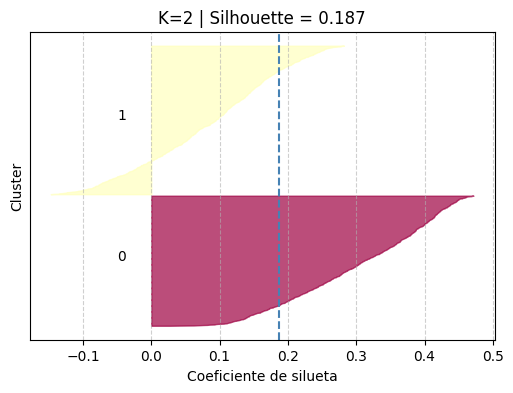

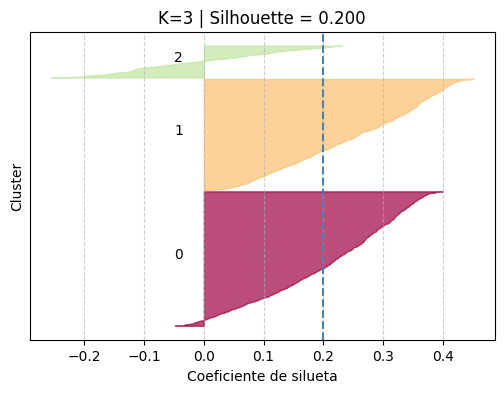

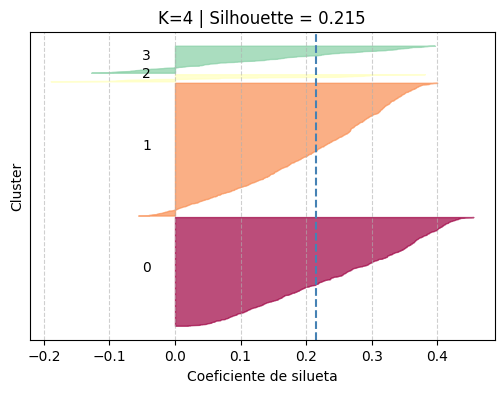

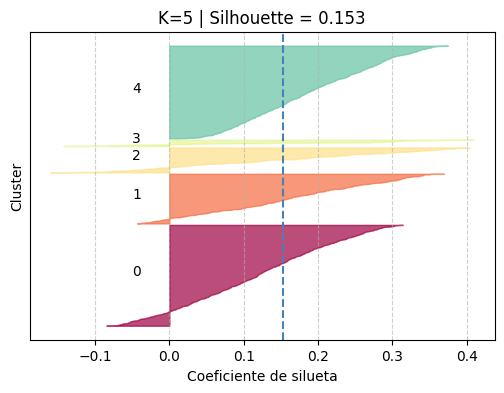

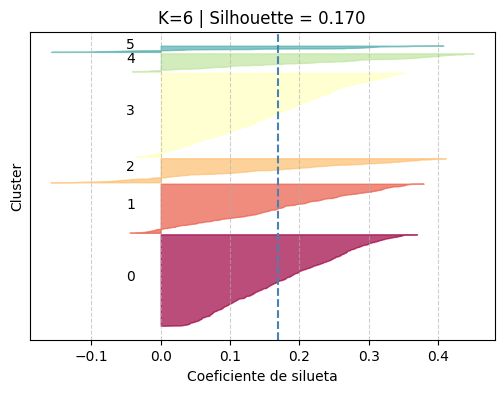

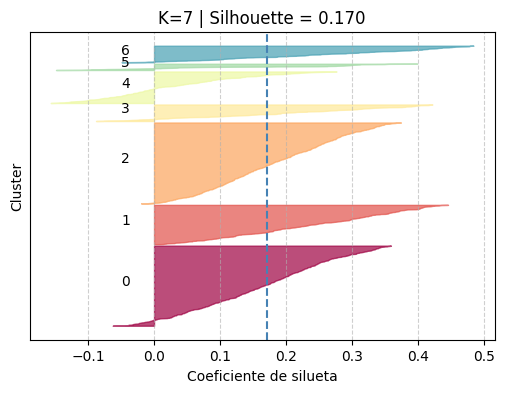

K-Means -> Mejor K global: 4 (Silhouette: 0.2151)


In [91]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# --- PARÁMETROS DE ENTRADA ---
k_min = 2
k_max = 7
# -----------------------------

# Rango de K a evaluar
k_values = range(k_min, k_max + 1)

kmeans_silhouettes = []
kmeans_labels_dict = {}

best_k_kmeans = k_min
best_sil_kmeans = -1
best_labels_kmeans = None

# 1. Entrenamiento y evaluación de K-Means
for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_k = kmeans.fit_predict(X_pca)
    
    sil_k = silhouette_score(X_pca, labels_k)
    kmeans_silhouettes.append(sil_k)
    kmeans_labels_dict[k] = labels_k
    
    # Actualizar si encontramos un mejor score de Silhouette
    if sil_k > best_sil_kmeans:
        best_sil_kmeans = sil_k
        best_k_kmeans = k
        best_labels_kmeans = labels_k

# Guardamos las etiquetas del mejor modelo en el DataFrame original
data['kmeans_cluster'] = best_labels_kmeans

# 2. Gráfico 1: Índice de la silueta vs número de clusters
plt.figure(figsize=(8, 4))
plt.plot(k_values, kmeans_silhouettes, marker='o', color='#9400D3', linewidth=2, label='Silhouette score')
plt.title('Índice de la silueta vs número de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Índice de la silueta')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 3. Gráficos de Silueta por Observación para cada K
for k in k_values:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    labels_k = kmeans_labels_dict[k]
    sil_avg = kmeans_silhouettes[k - k_min]
    sample_silhouette_values = silhouette_samples(X_pca, labels_k)
    
    y_lower = 10
    for i in range(k):
        # Agregar los valores de silueta para las muestras en el cluster i, y ordenarlas
        ith_cluster_sil_values = sample_silhouette_values[labels_k == i]
        ith_cluster_sil_values.sort()
        
        size_cluster_i = ith_cluster_sil_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        # Color usando un mapa de colores similar al del ejemplo
        color = cm.Spectral(float(i) / k)
        
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        # Etiquetar los clusters
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        
        # Calcular el nuevo y_lower para el próximo cluster
        y_lower = y_upper + 10
        
    ax.axvline(x=sil_avg, color="steelblue", linestyle="--")
    
    ax.set_title(f"K={k} | Silhouette = {sil_avg:.3f}")
    ax.set_xlabel("Coeficiente de silueta")
    ax.set_ylabel("Cluster")
    ax.set_yticks([])  # Limpiar las etiquetas del eje y
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    
    plt.show()

print(f"K-Means -> Mejor K global: {best_k_kmeans} (Silhouette: {best_sil_kmeans:.4f})")

- **Algoritmo 2 (Probabilístico / Basado en Distribuciones)**: **Gaussian Mixture Models (GMM)**. Es más flexible que K-Means, ya que permite clusters elípticos y modela la probabilidad de que un punto pertenezca a cada distribución.

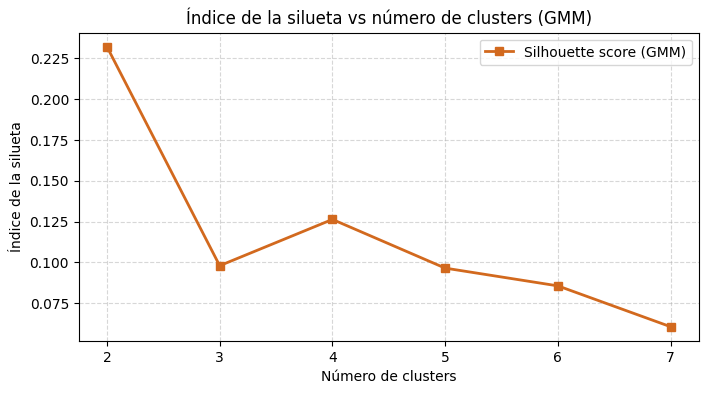

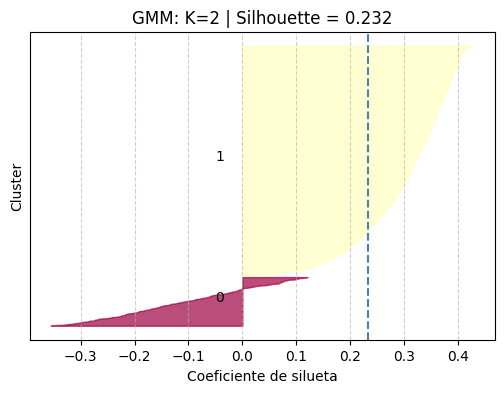

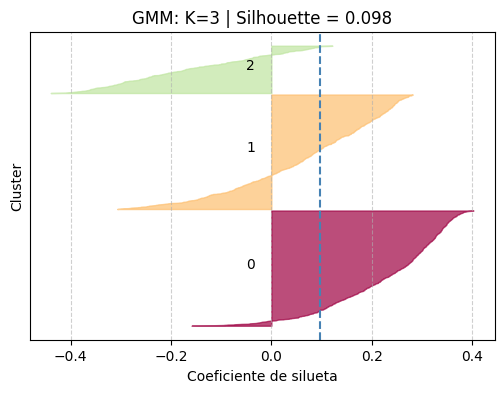

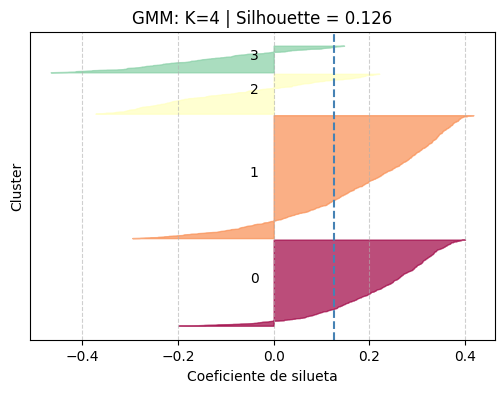

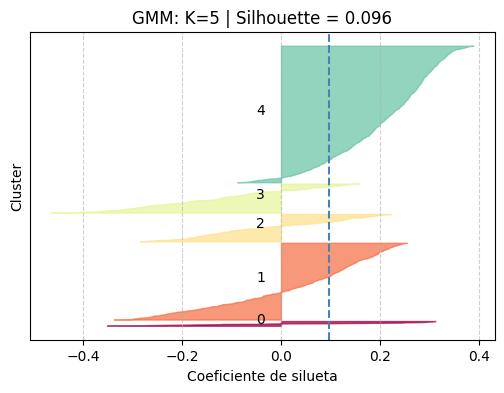

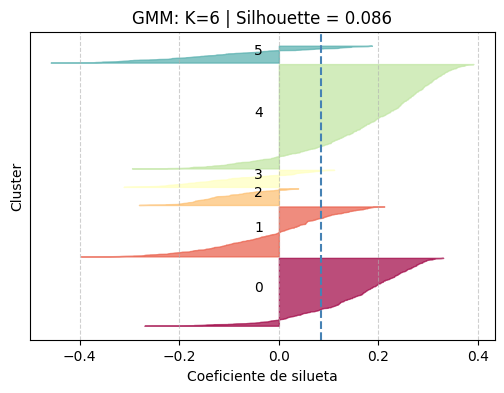

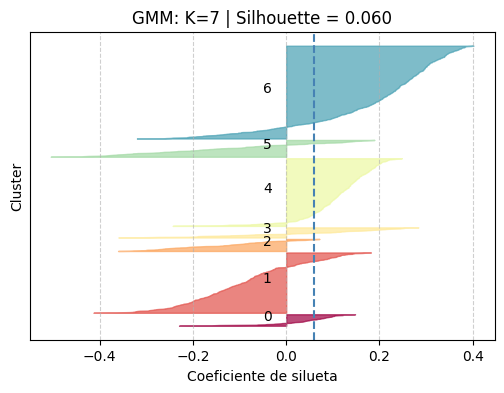

GMM -> Mejor K global: 2 (Silhouette: 0.2322)


In [92]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# --- PARÁMETROS DE ENTRADA ---
k_min = 2
k_max = 7
# -----------------------------

k_values = range(k_min, k_max + 1)

gmm_silhouettes = []
gmm_labels_dict = {}

best_k_gmm = k_min
best_sil_gmm = -1
best_labels_gmm = None

# 1. Entrenamiento y evaluación de GMM
for k in k_values:
    # covariance_type='full' permite que los clusters sean elípticos (no necesariamente esféricos como K-Means)
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    labels_k = gmm.fit_predict(X_pca)
    
    # Calcular Silhouette
    sil_k = silhouette_score(X_pca, labels_k)
    gmm_silhouettes.append(sil_k)
    gmm_labels_dict[k] = labels_k
    
    if sil_k > best_sil_gmm:
        best_sil_gmm = sil_k
        best_k_gmm = k
        best_labels_gmm = labels_k

# Guardamos las etiquetas en el DataFrame original
data['gmm_cluster'] = best_labels_gmm

# 2. Gráfico 1: Índice de la silueta vs número de clusters (GMM)
plt.figure(figsize=(8, 4))
plt.plot(k_values, gmm_silhouettes, marker='s', color='#D2691E', linewidth=2, label='Silhouette score (GMM)')
plt.title('Índice de la silueta vs número de clusters (GMM)')
plt.xlabel('Número de clusters')
plt.ylabel('Índice de la silueta')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 3. Gráficos de Silueta por Observación para cada K
for k in k_values:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    labels_k = gmm_labels_dict[k]
    sil_avg = gmm_silhouettes[k - k_min]
    sample_silhouette_values = silhouette_samples(X_pca, labels_k)
    
    y_lower = 10
    for i in range(k):
        ith_cluster_sil_values = sample_silhouette_values[labels_k == i]
        ith_cluster_sil_values.sort()
        
        size_cluster_i = ith_cluster_sil_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.Spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
        
    ax.axvline(x=sil_avg, color="steelblue", linestyle="--")
    
    ax.set_title(f"GMM: K={k} | Silhouette = {sil_avg:.3f}")
    ax.set_xlabel("Coeficiente de silueta")
    ax.set_ylabel("Cluster")
    ax.set_yticks([])
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    
    plt.show()

print(f"GMM -> Mejor K global: {best_k_gmm} (Silhouette: {best_sil_gmm:.4f})")

### 3.c Evaluación, Comparación y Selección de la Solución



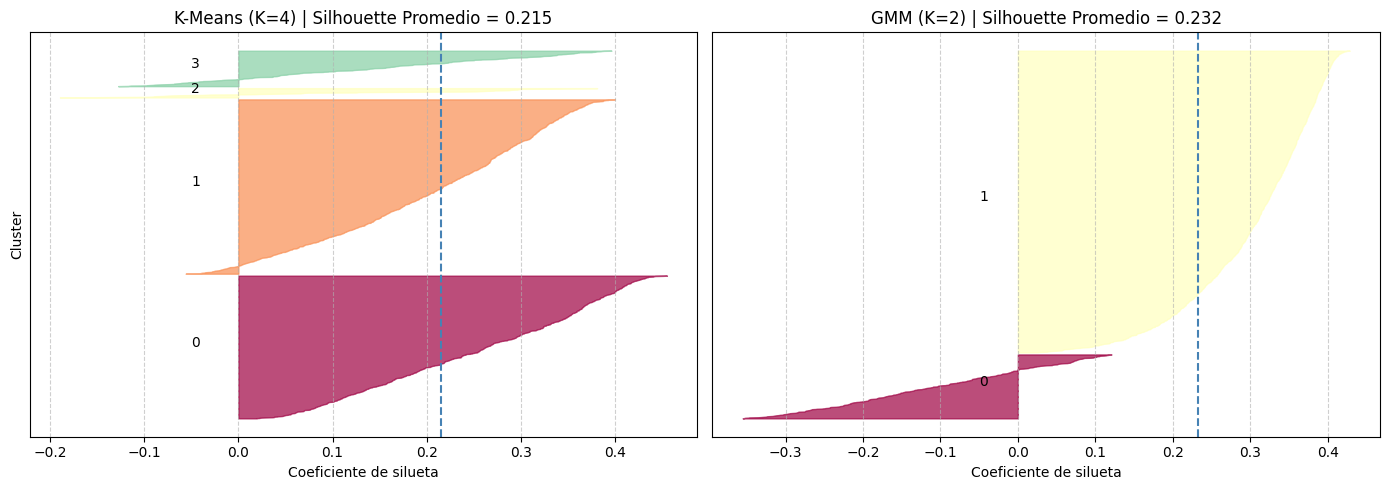

In [93]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.metrics import silhouette_samples

# Obtenemos las etiquetas y promedios ya calculados de K-Means (K=4) y GMM (K=2)
k_kmeans = 4
labels_kmeans_4 = kmeans_labels_dict[k_kmeans]
sil_avg_kmeans = kmeans_silhouettes[k_kmeans - k_min]

k_gmm = 2
labels_gmm_2 = gmm_labels_dict[k_gmm]
sil_avg_gmm = gmm_silhouettes[k_gmm - k_min]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: K-Means (K=4) ---
y_lower = 10
sample_silhouette_values = silhouette_samples(X_pca, labels_kmeans_4)
for i in range(k_kmeans):
    ith_cluster_sil_values = sample_silhouette_values[labels_kmeans_4 == i]
    ith_cluster_sil_values.sort()
    size_cluster_i = ith_cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.Spectral(float(i) / k_kmeans)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10
ax1.axvline(x=sil_avg_kmeans, color="steelblue", linestyle="--")
ax1.set_title(f"K-Means (K={k_kmeans}) | Silhouette Promedio = {sil_avg_kmeans:.3f}")
ax1.set_xlabel("Coeficiente de silueta")
ax1.set_ylabel("Cluster")
ax1.set_yticks([])
ax1.grid(axis='x', linestyle='--', alpha=0.6)

# --- Plot 2: GMM (K=2) ---
y_lower = 10
sample_silhouette_values = silhouette_samples(X_pca, labels_gmm_2)
for i in range(k_gmm):
    ith_cluster_sil_values = sample_silhouette_values[labels_gmm_2 == i]
    ith_cluster_sil_values.sort()
    size_cluster_i = ith_cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.Spectral(float(i) / k_gmm)
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10
ax2.axvline(x=sil_avg_gmm, color="steelblue", linestyle="--")
ax2.set_title(f"GMM (K={k_gmm}) | Silhouette Promedio = {sil_avg_gmm:.3f}")
ax2.set_xlabel("Coeficiente de silueta")
ax2.set_yticks([])
ax2.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

- **Mejor Modelo Global:** **K-Means (K=4)**. 

- **Justificación y Análisis de Siluetas:** 
Aunque el modelo GMM ($K=2$) alcanzó un puntaje promedio de Silhouette levemente mayor (0.232 frente al 0.215 de K-Means), este valor es engañoso. Al observar los perfiles de silueta, se evidencia que un cluster entero en GMM está compuesto por coeficientes negativos, lo que representa una partición fallida donde esos puntos están más cerca del cluster vecino que del propio.

Por el contrario, **K-Means ($K=4$)** presenta una partición geométricamente equilibrada y útil. Sus grupos muestran buena cohesión interna y la mayoría de las observaciones superan el umbral promedio, garantizando una segmentación estructuralmente sólida que nos permitirá perfilar las comunidades socioeconómicas de manera confiable.

--- Frecuencias Absolutas por Cluster ---


HighCrime,0,1,Total
kmeans_cluster,,,
0,784,2,786
1,897,63,960
2,31,21,52
3,172,24,196
Total,1884,110,1994



--- Porcentaje de Baja Criminalidad (False) vs Alta Criminalidad (True) (%) ---


HighCrime,0,1
kmeans_cluster,,
0,99.75%,0.25%
1,93.44%,6.56%
2,59.62%,40.38%
3,87.76%,12.24%


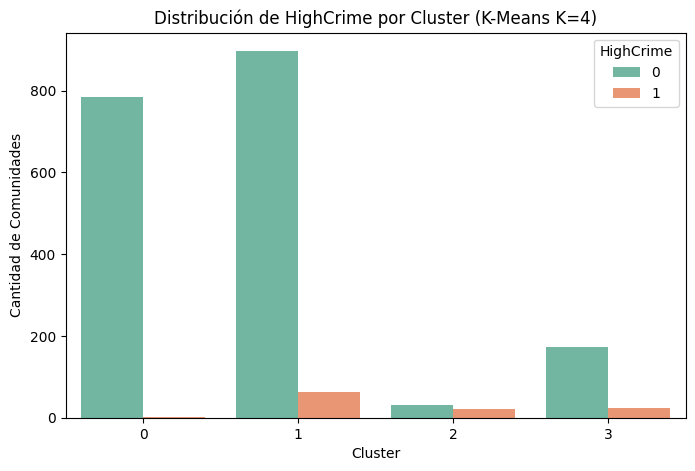


--- Top 5 Características socioeconómicas con mayor contraste promedio ---


,HousVacant,NumUnderPov,population,numbUrban,PctNotSpeakEnglWell
kmeans_cluster,,,,,
0,0.034,0.010,0.028,0.040,0.093
1,0.076,0.052,0.044,0.045,0.081
2,0.764,0.696,0.678,0.683,0.298
3,0.069,0.083,0.078,0.088,0.682


In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Asignamos las etiquetas del modelo ganador (K-Means con K=4) al DataFrame principal 'data'
# Usamos el diccionario de etiquetas generado en la celda de entrenamiento
col_cluster = "kmeans_cluster"
data[col_cluster] = kmeans_labels_dict[4]

# 2. Tabla cruzada de frecuencias y proporciones por cluster
ct_abs = pd.crosstab(
    data[col_cluster],
    data["HighCrime"],
    margins=True,
    margins_name="Total",
)
ct_prop = pd.crosstab(
    data[col_cluster], data["HighCrime"], normalize="index"
) * 100

print("--- Frecuencias Absolutas por Cluster ---")
display(ct_abs)

print("\n--- Porcentaje de Baja Criminalidad (False) vs Alta Criminalidad (True) (%) ---")
display(ct_prop.round(2).astype(str) + "%")

# Gráfico de countplot
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x=col_cluster, hue='HighCrime', palette='Set2')
plt.title('Distribución de HighCrime por Cluster (K-Means K=4)')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de Comunidades')
plt.legend(title='HighCrime')
plt.show()

# 3. Profiling: Top 5 variables socioeconómicas que más diferencian a los clusters
cols_to_groupby = numeric_cols + [col_cluster]
data_numeric_only = data[cols_to_groupby].copy()

# Forzamos la conversión a numérico para evitar errores con columnas de tipo 'object'
data_numeric_only = data_numeric_only.apply(pd.to_numeric, errors='coerce')

# Ahora sí agrupamos y promediamos
cluster_means = data_numeric_only.groupby(col_cluster).mean()
varianza_entre_clusters = cluster_means.std(axis=0).sort_values(ascending=False)
top_5_features = varianza_entre_clusters.head(5).index.tolist()

print("\n--- Top 5 Características socioeconómicas con mayor contraste promedio ---")
display(cluster_means[top_5_features].round(3))

In [95]:
# 4. Observaciones representativas de cada cluster (Ejemplos de comunidades)
# Mostramos 3 comunidades de ejemplo por cada cluster junto con sus valores en las variables clave.
print("--- Observaciones representativas de cada cluster ---")
for i in range(4):
    print(f"\nCluster {i} (Proporción de Alta Criminalidad: {ct_prop.loc[i, 1]:.2f}%):")
    
    # Buscamos si hay columnas de nombre de comunidad o estado para identificarlas
    cols_identificadoras = ['communityname', 'communityName', 'state', 'stateName']
    cols_show = [c for c in cols_identificadoras if c in data.columns]
    
    # Agregamos las variables top del profiling
    cols_show.extend(['population', 'HousVacant', 'NumUnderPov'])
    
    # Mostramos 3 ejemplos reales que cayeron en este cluster
    ejemplos = data[data[col_cluster] == i][cols_show].head(3)
    display(ejemplos)

--- Observaciones representativas de cada cluster ---

Cluster 0 (Proporción de Alta Criminalidad: 0.25%):


,communityname,state,population,HousVacant,NumUnderPov
0,Lakewoodcity,8,0.19,0.21,0.08
3,Willingborotownship,34,0.04,0.01,0.01
4,Bethlehemtownship,42,0.01,0.01,0.00



Cluster 1 (Proporción de Alta Criminalidad: 6.56%):


,communityname,state,population,HousVacant,NumUnderPov
1,Tukwilacity,53,0.00,0.02,0.01
2,Aberdeentown,24,0.00,0.01,0.01
8,Hendersoncity,21,0.03,0.04,0.04



Cluster 2 (Proporción de Alta Criminalidad: 40.38%):


,communityname,state,population,HousVacant,NumUnderPov
21,Jacksonvillecity,12,1.00,1.00,0.76
109,Tucsoncity,4,0.64,1.00,0.72
177,JerseyCitycity,34,0.35,0.44,0.39



Cluster 3 (Proporción de Alta Criminalidad: 12.24%):


,communityname,state,population,HousVacant,NumUnderPov
7,Selmacity,6,0.01,0.01,0.03
10,DalyCitycity,6,0.13,0.06,0.06
20,Modestocity,6,0.25,0.15,0.19


### 3.d Conclusiones Finales: Interpretación de los Clusters

A continuación se responde a los requerimientos de análisis sobre los grupos descubiertos por K-Means (K=4):

**1. Observaciones representativas de cada cluster**
* **Cluster 0 (Baja criminalidad):** Ejemplos como *Lakewoodcity*, *Willingborotownship* o *Bethlehemtownship*. Son zonas que representan comunidades muy estables, con bajísima pobreza y casi sin propiedades vacantes.
* **Cluster 2 (Riesgo crítico):** Ejemplos como *Jacksonvillecity*, *Tucsoncity* o *JerseyCitycity*. Representan las grandes áreas urbanas y metropolitanas con profunda degradación social.

**2. Características que distinguen a los diferentes grupos**
El perfil socioeconómico está marcadamente diferenciado por el volumen poblacional y la precariedad estructural. El **Cluster 2** se distingue abismalmente por abarcar núcleos poblacionales gigantescos (`population`, `numbUrban`), sufriendo de un nivel alarmante de personas viviendo bajo la línea de pobreza (`NumUnderPov`) y una masiva cantidad de viviendas desocupadas o abandonadas (`HousVacant`). En el extremo opuesto, el **Cluster 0** agrupa comunidades sin problemas crónicos de vivienda ni pobreza extrema. Los Clusters 1 y 3 representan escenarios intermedios (por ejemplo, *Modestocity* o *Tukwilacity*).

**3. Información que aportan los clusters sobre los datos y el problema analizado**
El agrupamiento demostró que la estructura socioeconómica de los datos predice intrínsecamente la criminalidad, incluso sin utilizar etiquetas (aprendizaje no supervisado). El algoritmo logró mapear la violencia de forma automática: el **Cluster 2** concentra una enorme tasa de criminalidad alta (40.38%), revelando que el problema de los crímenes violentos en EE.UU. (según este dataset) no es aleatorio, sino un fenómeno directamente anclado a la marginación económica (pobreza extrema) y al deterioro urbano (casas vacías) dentro de los centros altamente densificados.

## 4. Visualización e Interpretación con UMAP (Opcional)

A partir de los datos preprocesados, aplicaremos UMAP para obtener una proyección no lineal en 2D. A diferencia de PCA (que busca varianza global), UMAP es excelente para preservar la estructura topológica local, lo que nos ayudará a visualizar agrupamientos naturales y distribuciones de densidad.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


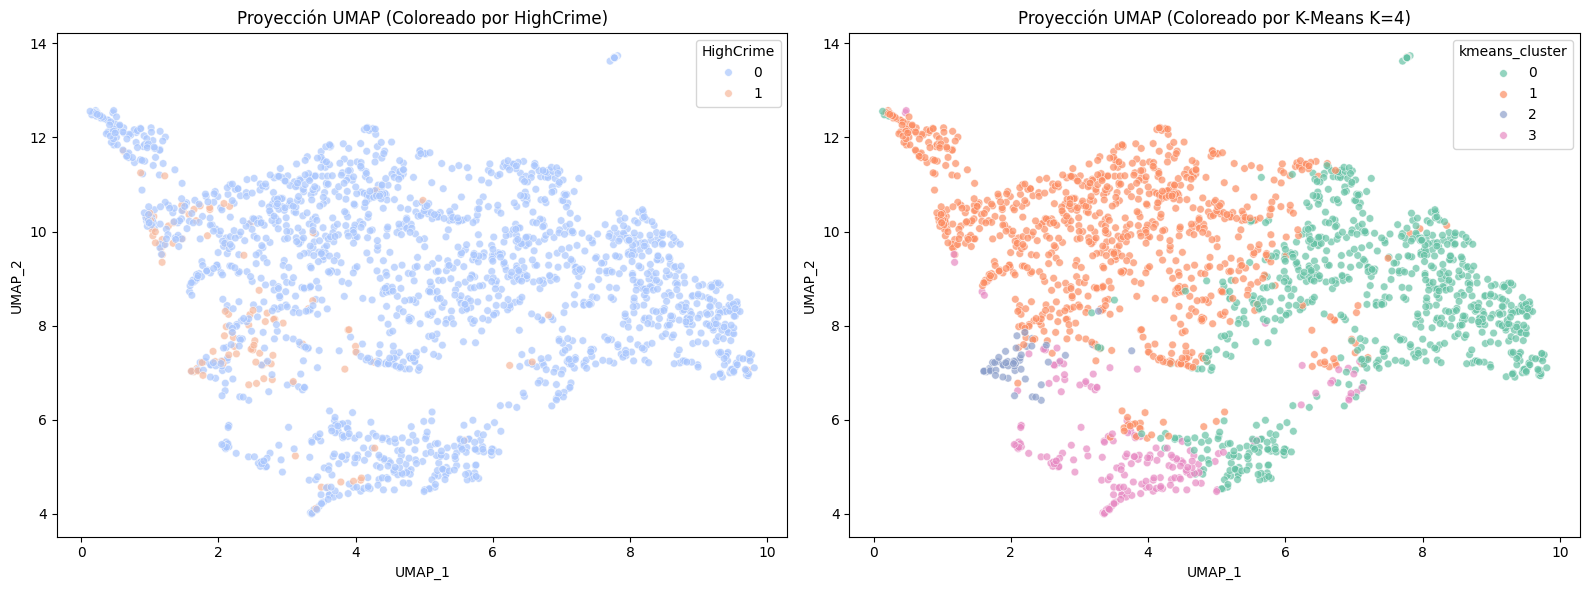

In [96]:
# Instalar UMAP si no está disponible en el entorno (descomenta la línea de abajo si te arroja error de módulo no encontrado)
# !pip install umap-learn

import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aplicar UMAP sobre los datos preprocesados (X_processed)
# Se usa X_processed y no X_pca para que UMAP capture la topología sobre todas las dimensiones originales normalizadas.
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_processed)

# Guardar las 2 dimensiones en el DataFrame para facilitar el gráfico
data['UMAP_1'] = X_umap[:, 0]
data['UMAP_2'] = X_umap[:, 1]

# 2. Visualización Comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Coloreado por la variable Target (HighCrime)
sns.scatterplot(
    data=data, 
    x='UMAP_1', y='UMAP_2', 
    hue='HighCrime', 
    palette='coolwarm', 
    alpha=0.7, 
    s=30,
    ax=axes[0]
)
axes[0].set_title('Proyección UMAP (Coloreado por HighCrime)')

# Gráfico B: Coloreado por los Clusters de K-Means (K=4)
sns.scatterplot(
    data=data, 
    x='UMAP_1', y='UMAP_2', 
    hue='kmeans_cluster', 
    palette='Set2', 
    alpha=0.7, 
    s=30,
    ax=axes[1]
)
axes[1].set_title('Proyección UMAP (Coloreado por K-Means K=4)')

plt.tight_layout()
plt.show()

### Conclusiones sobre la representación UMAP

- **Separabilidad y Agrupamientos:** La proyección UMAP revela que los datos no forman "islas" completamente aisladas, sino un gran continuo con distintas densidades y subregiones (como penínsulas). A pesar de esto, la topología tiene mucho sentido. Si miramos el gráfico de la derecha, vemos que K-Means logró dividir este continuo de forma espacialmente muy coherente: el **Cluster 0** (verde) domina por completo todo el lado derecho del mapa, mientras que los clusters de mayor riesgo (**2** y **3**) ocupan los extremos inferiores izquierdos.

- **Relación entre Clusters y Criminalidad:** Al comparar ambos gráficos, la correspondencia visual es impresionante. En el mapa de la izquierda, la gran mayoría de las comunidades con alta criminalidad (`HighCrime` = 1, puntos naranjas) se agrupan fuertemente en el cuadrante inferior izquierdo. Al observar el mapa de la derecha, notamos que esa región geográfica es **exactamente la misma** que K-Means delimitó como el **Cluster 2** (rosa) y el **Cluster 3** (violeta). 

**Conclusión Final:** Esta visualización confirma el éxito rotundo del pipeline no supervisado. El algoritmo logró encapsular matemáticamente las zonas de alta criminalidad basándose *únicamente* en la similitud de las variables socioeconómicas (sin conocer el Target), lo que demuestra que la criminalidad está intrínsecamente ligada al perfil estructural y económico de las comunidades.